# Lecture : Shallow Graph Learning

## Lab 04 : DeepWalk - Solution

### Xavier Bresson, Guoji Fu   

Perozzi, Al-Rfou, Skiena, DeepWalk: Online learning of social representations, 2014  
https://arxiv.org/pdf/1403.6652.pdf

Notebook goals :<br>
• Design a random walk extractor <br>
• Implement the deepwalk technique <br>
• Compare visually the deepwalk embedding with networkx visualization <br>


In [1]:
# For Google Colaboratory
import sys, os
if 'google.colab' in sys.modules:
    # mount google drive
    from google.colab import drive
    drive.mount('/content/gdrive')
    path_to_file = '/content/gdrive/My Drive/CS5284_2026_codes/05_Shallow_Learning'
    print(path_to_file)
    # change current path to the folder containing "path_to_file"
    os.chdir(path_to_file)
    !pwd
    !pip install rdkit==2023.09.6 # Install RDKit
    !pip install dgl==1.0.2 # Install DGL


In [2]:
# Libraries
import pickle
import sys; sys.path.insert(0, 'lib/')
from lib.utils import Molecule
from rdkit import Chem
import torch
import torch.nn as nn
import networkx as nx
import matplotlib.pyplot as plt
import random
from lib.utils import compute_ncut


## Load dataset and select one molecule

Loading data
tensor([0, 5, 0, 0, 0, 0, 1, 2, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0, 4, 0, 0, 0, 2])
tensor([ 0,  0,  1,  2,  3,  4,  0,  0,  5,  6,  7,  8,  9, 10,  1, 11,  1, 12,
         0, 13, 14, 15,  2])
tensor([[0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 1, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
        [0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 0],
        [0, 0, 0, 0, 1, 0, 2, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 1, 0, 2, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 0, 0, 0, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
        [0

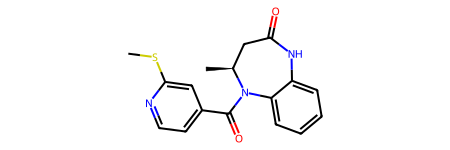

In [3]:
print('Loading data')
data_folder_pytorch = 'datasets/ZINC_pytorch/'
with open(data_folder_pytorch+"train_pytorch.pkl","rb") as f:
    dataset=pickle.load(f)

# Select one molecule
idx = 12
mol = dataset[idx]
print(mol.atom_type)
print(mol.atom_type_pe)
print(mol.bond_type)
print(mol.bag_of_atoms)
print(mol.logP_SA_cycle_normalized)
print(mol.smile)
Chem.MolFromSmiles(mol.smile)


## Exercise 1 : Design a random walk extractor

### Question 1.1 : Implement a class that generates a random walk path.

Hints:
- Sample the next node from the RW probability `prob_j = RW[i,:]`.
- Sample from the categorical distribution with `torch.distributions.Categorical(prob_j).sample()`.


In [4]:
class sample_RW_path:

    def __init__(self, num_steps, RW):
        self.num_steps = num_steps # number of steps
        self.RW = RW # random walk matrix
        self.num_nodes = RW.size(0) # number of nodes

    def sample_walk(self, idx_start):
        idx = torch.tensor(idx_start).long() # starting index of the walk
        RWpath = [idx] # random walk path
        for _ in range(self.num_steps-1):
            ########################################
            # YOUR CODE START
            # sample the next node from the categorical distribution RW[i,:]
            # use torch.distributions.Categorical(prob).sample()
            ########################################

            idx = torch.distributions.Categorical(self.RW[idx,:]).sample()

            ########################################
            # YOUR CODE END
            ########################################

            RWpath.append(idx) # append sampled node to the path
        RWpath = torch.stack(RWpath).flatten() # path format = torch.tensor([idx_1, idx_2, ..., idx_num_steps])
        return RWpath



### Question 1.2 : Use the previously defined function to sample a random walk path.

Hints:
- Step 1: Compute the RW operator with $RW = D^{-1}A$.
- Step 2: Choose the number of RW steps.
- Step 3: Use `sample_RW_path()` to instantiate a RW class.
- Step 4: Apply `sample_walk()` to extract a RW path.
  

RW: tensor([ 3,  2,  3,  2, 22,  2, 22,  2])


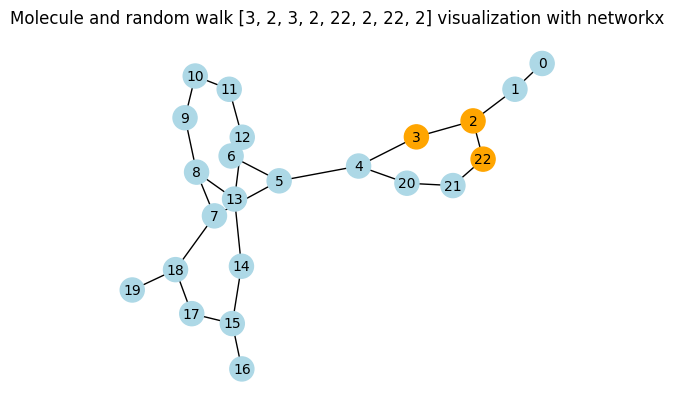

In [11]:
A = (mol.bond_type>0).float() # Adjacency matrix
D = A.sum(dim=1) # Degree vector (row degrees)

########################################
# YOUR CODE START
########################################

# Step 1: # Compute the RW operator
# Compute the inverse degree matrix
Dinv = (D.clamp_min(1)**(-1)).diag() # clamp handles possible isolated nodes

# Compute RW matrix
RW = torch.mm(Dinv,A) # RW matrix

# Step 2: choose the number of RW steps
num_RW_steps = T = 8 # QM9

# Step 3: instantiate RW class
generator = sample_RW_path(num_RW_steps, RW)

# Step 4: sample RW path starting with index=7
idx_start = torch.randint(0, A.size(0), (1,)).item()
walk = generator.sample_walk(idx_start)

########################################
# YOUR CODE END
########################################

print('RW:',walk)

# Visualise the RW
fig = plt.figure()
ax = fig.add_subplot(111)
A_nx = nx.from_numpy_array(A.numpy())
# Color random-walk nodes
walk_nodes = set(walk.tolist())
node_color = ['orange' if i in walk_nodes else 'lightblue' for i in range(A.size(0))]
nx.draw(A_nx, ax=ax, node_color=node_color, with_labels=True, font_size=10)
ax.title.set_text(f'Molecule and random walk {walk.tolist()} visualization with networkx')
plt.show()


## Exercise 2 : Implement DeepWalk-style node embeddings with Skip-gram negative sampling

For pedagogical simplicity, this exercise uses a **single (tied) node-embedding table** for both center and context nodes. The original DeepWalk paper uses Skip-gram with hierarchical softmax.


### Question 2.1 : Implement a DeepWalk-style network and apply it to molecular graphs.

For a sampled walk $R=(v_1,\ldots,v_T)$, each occurrence $v_t$ is used as a center node, and its positive context contains the walk occurrences within a window of radius $w$ around position $t$.

Instructions:
- Step 1: Extract the center embedding $h_i$ for node occurrence $i=v_t$.
- Step 2: Extract the embeddings $h_j$ for context occurrences $j\in C_t=(v_{\max(1,t-w)},\ldots,v_{t-1},v_{t+1},\ldots,v_{\min(T,t+w)})$, \
  with $w$ being the window size (do not use a set: repeated occurrences matter).
- Step 3: For each positive pair $(i,j)$, sample `num_negative` negative nodes $k_r\sim q$, where $q(k)=1/|V|$ is uniform over the graph nodes.
- Step 4: Use the negative-sampling loss
  $$\ell(i,j)=-\log\sigma(h_i^T h_j)-\sum_{r=1}^{K}\log\sigma(-h_i^T h_{k_r}).$$


In [6]:
class deepwalk_net(nn.Module):

    def __init__(self, num_nodes, hidden_dim, num_negative, window_size):
        super(deepwalk_net, self).__init__()
        print(num_nodes, hidden_dim)
        self.num_nodes = num_nodes
        self.num_negative = num_negative
        self.window_size = window_size
        self.node_embedding = nn.Embedding(num_nodes, hidden_dim)

    def forward(self, walk):
        loss = []

        # Each POSITION t in the walk is a center occurrence.
        # Repeated node IDs at different positions are therefore kept.
        for t in range(walk.numel()):
            i = walk[t]
        
            ########################################
            # YOUR CODE START
            ########################################
        
            # Step 1: extract center embedding h_i
            hi = self.node_embedding(i).unsqueeze(0)  # size=(1,d)
        
            # Step 2: context occurrences within a window around position t
            left = max(0, t - self.window_size)                  # t-w, ..., t-1
            right = min(walk.numel(), t + self.window_size + 1)  # t+1, ..., t+w
            context = torch.cat((walk[left:t], walk[t+1:right])) # size=(C,), with C <= 2w
            hj = self.node_embedding(context)                    # size=(C,d)
            positive_scores = torch.mm(hj, hi.transpose(1, 0))   # Positive scores h_i^T h_j, size=(C,1) = (C,d) x (d,1)
        
            # Step 3: sample K negatives independently for each positive pair
            #         q(k) = 1/|V|, i.e. uniform over all graph nodes
            k = torch.randint(low=0, high=self.num_nodes, size=(context.numel(), self.num_negative)) # size=(C,K)
            hk = self.node_embedding(k)                                         # size=(C,K,d)
            negative_scores = torch.matmul(hk, hi.transpose(1, 0)).squeeze(-1)  # size=(C,K)
        
            ########################################
            # YOUR CODE END
            ########################################
        
            # Step 4: Skip-gram negative-sampling loss
            #         l(i,j) = -log sigma(h_i^T h_j)
            #                  -sum_r log sigma(-h_i^T h_{k_r})
            loss_pairs = - torch.nn.functional.logsigmoid(positive_scores.squeeze(-1)) \
                         - torch.nn.functional.logsigmoid(-negative_scores).sum(dim=1)  # size=(C,)
            loss.append(loss_pairs)
        
        return torch.cat(loss).mean()

        

### Question 2.2 : Instantiate a DeepWalk-style network

Instructions:
- Select the context-window radius and the number of negative samples.
- Instantiate `deepwalk_net()`.
- Evaluate and compare the embeddings obtained with different context-window sizes and numbers of negative samples.


In [7]:
num_nodes = A.size(0)

########################################
# YOUR CODE START
########################################

# Hyperparameters
hidden_dim = 2       # 2D only for visualization in this lab
window_size = 2     # context-window radius along the random walk
num_negative = 4    # number of negative samples per positive pair

# Remove net if it exists
try:
    del net
except NameError:
    pass
    
net = deepwalk_net(num_nodes, hidden_dim, num_negative, window_size)

########################################
# YOUR CODE END
########################################

print(net)


23 2
deepwalk_net(
  (node_embedding): Embedding(23, 2)
)


### Train the DeepWalk-style network


In [8]:
# Train the network
optimizer = torch.optim.Adam(net.parameters(), lr=0.003)
for iter in range(400): 
    loss_epoch = 0.0
    for idx in torch.randperm(num_nodes).tolist(): # shuffle ordering of starting nodes
        walk = generator.sample_walk(idx)
        loss = net(walk)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_epoch += loss.detach()

    # Do not recenter the embeddings here: dot-product Skip-gram losses are not translation invariant.

    # plot the loss value
    if not iter % 10:
        print(iter, loss_epoch / num_nodes)


0 tensor(4.0206)
10 tensor(3.6486)
20 tensor(3.5251)
30 tensor(3.4658)
40 tensor(3.4589)
50 tensor(3.3861)
60 tensor(3.3793)
70 tensor(3.3512)
80 tensor(3.3830)
90 tensor(3.3454)
100 tensor(3.3345)
110 tensor(3.3610)
120 tensor(3.3425)
130 tensor(3.3617)
140 tensor(3.3292)
150 tensor(3.3302)
160 tensor(3.3588)
170 tensor(3.3623)
180 tensor(3.3115)
190 tensor(3.3305)
200 tensor(3.3470)
210 tensor(3.3084)
220 tensor(3.3641)
230 tensor(3.3107)
240 tensor(3.2962)
250 tensor(3.3174)
260 tensor(3.3355)
270 tensor(3.3101)
280 tensor(3.3401)
290 tensor(3.3250)
300 tensor(3.3149)
310 tensor(3.3076)
320 tensor(3.3155)
330 tensor(3.3159)
340 tensor(3.3368)
350 tensor(3.3403)
360 tensor(3.3434)
370 tensor(3.3504)
380 tensor(3.3506)
390 tensor(3.3155)


### Visualize the learned node embeddings in 2D


tensor([[-0.4312, -0.4864],
        [-0.5345, -0.7102],
        [-0.4703, -0.7765],
        [-0.1473, -0.6953],
        [ 0.2662, -0.7269],
        [ 0.6753, -0.4022],
        [ 0.4733, -0.3240],
        [ 0.5654,  0.2180],
        [-0.0786,  0.6170],
        [-0.4947,  0.6360],
        [-0.7592,  0.5653],
        [-0.7638,  0.5676],
        [-0.6103,  0.6646],
        [-0.2685,  0.7230],
        [ 0.1107,  0.5910],
        [ 0.6623,  0.5865],
        [ 0.5068,  0.2829],
        [ 0.6736,  0.2797],
        [ 0.8576,  0.2035],
        [ 0.5904,  0.1573],
        [-0.1201, -0.7101],
        [-0.3437, -0.6987],
        [-0.5180, -0.6819]]) torch.Size([23, 2])


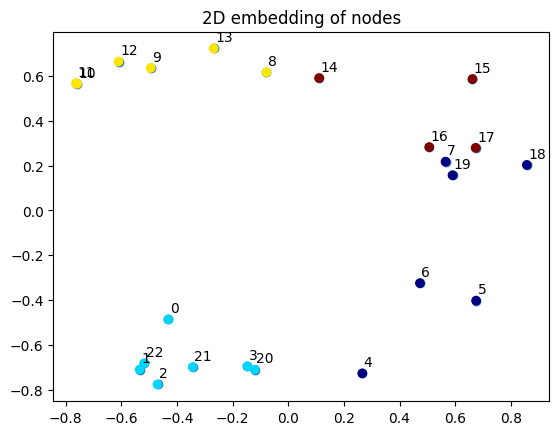

In [9]:
# Visualize the 2D coordinates of the node embeddings
x = net.node_embedding.weight.detach()
print(x,x.size())

# plot 2D coordinates
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(x[:,0], x[:,1])
idx = list(range(num_nodes))
C = compute_ncut(A.long(), 4)
ax.scatter(x[:,0], x[:,1], c=C, cmap='jet')
for i, txt in enumerate(idx):
    ax.annotate(txt, (x[:,0][i], x[:,1][i]), textcoords="offset points", xytext=(1,5))
ax.title.set_text('2D embedding of nodes')
plt.show()

### Question 2.3 : Compare visually the learned embedding with the NetworkX visualization


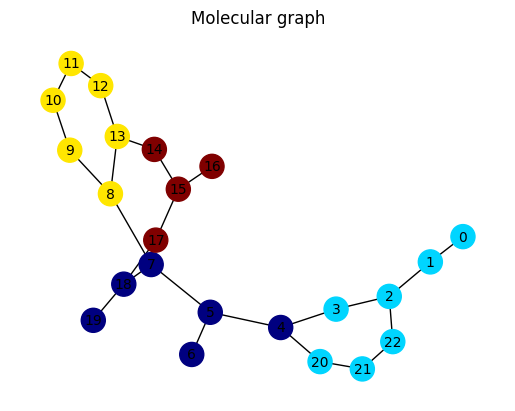

In [10]:
# Compare with graph edges
fig = plt.figure()
ax = fig.add_subplot(111)
nx.draw(A_nx, ax=ax, node_color=C, cmap='jet', with_labels=True, font_size=10) # visualise node indexes
ax.title.set_text('Molecular graph')
plt.show()
